In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from titlecase import titlecase

In [15]:
# load dataset
data = pd.read_csv(r"../Data/Raw Data/FMCG_data.csv", encoding="latin1")

In [16]:
# dataset overview
print("=" * 40)
print("DATASET OVERVIEW")

# rows and columns
print("=" * 40)
print(f"Jumlah Baris : {data.shape[0]}")
print(f"Jumlah Kolom : {data.shape[1]}")

# columns name
print("=" * 40)
print("Nama Kolom :")
for (index, column) in enumerate(data.columns, start = 1) :
    print(f"{index}. {column}")

# data types
print("=" * 40)
print("=" * 40)
print("Nama dan Tipe Data Kolom : ")
df_dtypes = pd.DataFrame({
    "Nama kolom" : data.dtypes.index,
    "Tipe Data" : data.dtypes.values
})
display(df_dtypes.style.hide(axis = "index"))

# preview dataset
print("=" * 40)
print("Preview Data : ")
display(data.head(10))

DATASET OVERVIEW
Jumlah Baris : 25000
Jumlah Kolom : 24
Nama Kolom :
1. Ware_house_ID
2. WH_Manager_ID
3. Location_type
4. WH_capacity_size
5. zone
6. WH_regional_zone
7. num_refill_req_l3m
8. transport_issue_l1y
9. Competitor_in_mkt
10. retail_shop_num
11. wh_owner_type
12. distributor_num
13. flood_impacted
14. flood_proof
15. electric_supply
16. dist_from_hub
17. workers_num
18. wh_est_year
19. storage_issue_reported_l3m
20. temp_reg_mach
21. approved_wh_govt_certificate
22. wh_breakdown_l3m
23. govt_check_l3m
24. product_wg_ton
Nama dan Tipe Data Kolom : 


Nama kolom,Tipe Data
Ware_house_ID,object
WH_Manager_ID,object
Location_type,object
WH_capacity_size,object
zone,object
WH_regional_zone,object
num_refill_req_l3m,int64
transport_issue_l1y,int64
Competitor_in_mkt,int64
retail_shop_num,int64


Preview Data : 


,Ware_house_ID,WH_Manager_ID,Location_type,WH_capacity_size,zone,WH_regional_zone,num_refill_req_l3m,transport_issue_l1y,Competitor_in_mkt,retail_shop_num,...,electric_supply,dist_from_hub,workers_num,wh_est_year,storage_issue_reported_l3m,temp_reg_mach,approved_wh_govt_certificate,wh_breakdown_l3m,govt_check_l3m,product_wg_ton
0,WH_100000,EID_50000,Urban,Small,West,Zone 6,3,1,2,4651,...,1,91,29.0,NaN,13,0,A,5,15,17115
1,WH_100001,EID_50001,Rural,Large,North,Zone 5,0,0,4,6217,...,1,210,31.0,NaN,4,0,A,3,17,5074
2,WH_100002,EID_50002,Rural,Mid,South,Zone 2,1,0,4,4306,...,0,161,37.0,NaN,17,0,A,6,22,23137
3,WH_100003,EID_50003,Rural,Mid,North,Zone 3,7,4,2,6000,...,0,103,21.0,NaN,17,1,A+,3,27,22115
4,WH_100004,EID_50004,Rural,Large,North,Zone 5,3,1,2,4740,...,1,112,25.0,2009.0,18,0,C,6,24,24071
5,WH_100005,EID_50005,Rural,Small,West,Zone 1,8,0,2,5053,...,1,152,35.0,2009.0,23,1,A+,3,3,32134
6,WH_100006,EID_50006,Rural,Large,West,Zone 6,8,0,4,4449,...,1,77,27.0,2010.0,24,0,B,3,6,30142
7,WH_100007,EID_50007,Rural,Large,North,Zone 5,1,0,4,7183,...,0,241,23.0,NaN,18,0,C,6,24,24093
8,WH_100008,EID_50008,Rural,Small,South,Zone 6,8,1,4,5381,...,1,124,22.0,2013.0,13,1,A+,5,2,18082
9,WH_100009,EID_50009,Rural,Small,South,Zone 6,4,3,3,3869,...,0,78,43.0,NaN,6,0,C,6,2,7130


In [17]:
# duplicate values 
print("=" * 40)
print("DUPLICATE RECORDS")

# check duplicate values
print("=" * 40)
print(f"Data duplikat : {data.duplicated().sum()}")

DUPLICATE RECORDS
Data duplikat : 0


In [18]:
# missing values 
print("=" * 40)
print("MISSING VALUES")

# check null values per columns
print("=" * 40)
display(pd.DataFrame({
    "Nama Kolom" : data.isna().sum().index,
    "Total Null" : data.isna().sum().values
}))

# drop unused columns in the analysis (wh_est_year 47.52% nan)
data.drop(columns=["wh_est_year"], inplace = True)

MISSING VALUES


,Nama Kolom,Total Null
0,Ware_house_ID,0
1,WH_Manager_ID,0
2,Location_type,0
3,WH_capacity_size,0
4,zone,0
5,WH_regional_zone,0
6,num_refill_req_l3m,0
7,transport_issue_l1y,0
8,Competitor_in_mkt,0
9,retail_shop_num,0


Data workers_num Nan


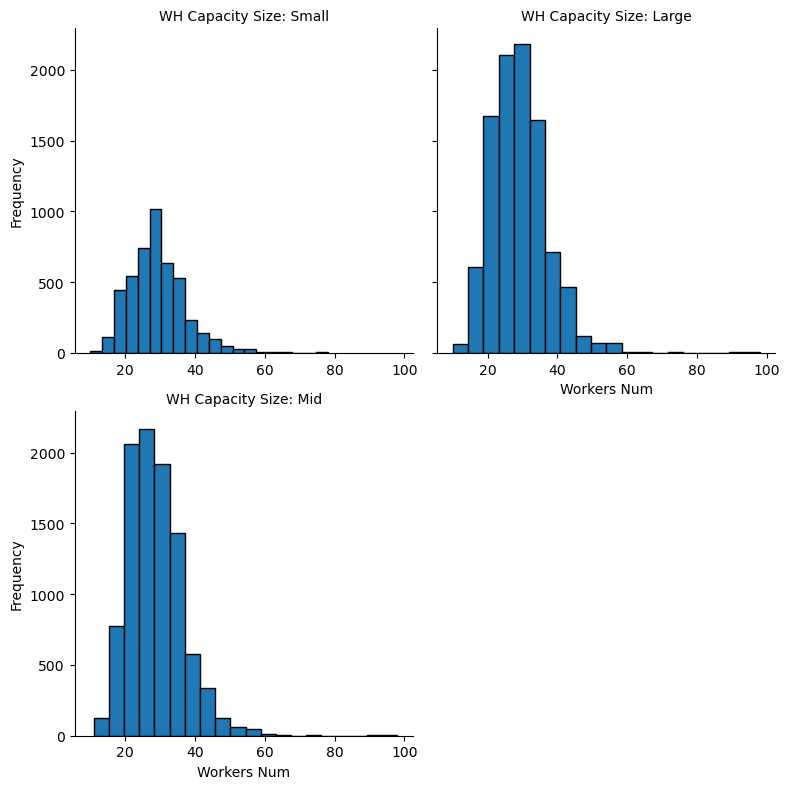

Jumlah null kolom workers_num : 0


In [19]:
# check data that has nan in workers_num column
print("=" * 40)
print("Data workers_num Nan")
print("=" * 40)

# check distribution workers num
g = sns.FacetGrid(data, col="WH_capacity_size", col_wrap=2, height=4, sharex=True)
g.map(plt.hist, "workers_num", bins=20, edgecolor="black")
for ax in g.axes.flat:
    ax.tick_params(axis='x', labelbottom=True)
g.set_axis_labels("Workers Num", "Frequency")
g.set_titles("WH Capacity Size: {col_name}")
plt.tight_layout()
plt.show()

# distribution right skewed
# impute with median 
data['workers_num'] = (
    data.groupby('WH_capacity_size')['workers_num']
      .transform(lambda x: x.fillna(x.median()))
)

# re-check null values columns workers num
print("=" * 40)
print(f"Jumlah null kolom workers_num : {data["workers_num"].isna().sum()}")

Data approved_wh_govt_certificate Nan


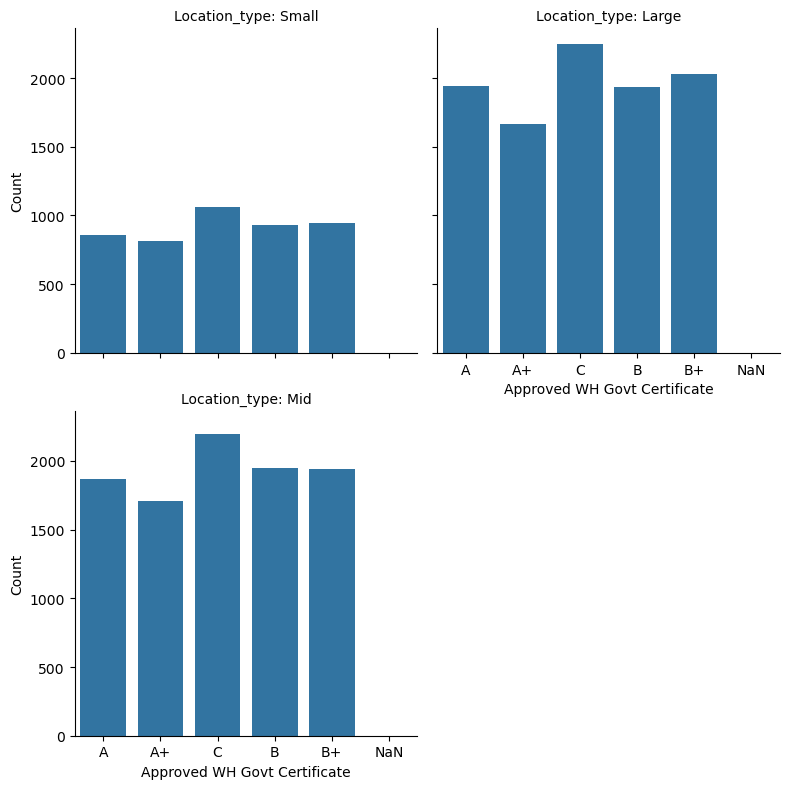

Jumlah null kolom approved_wh_govt_certificate : 908


In [20]:
# check data that has nan in approved_wh_govt_certificate column
print("=" * 40)
print("Data approved_wh_govt_certificate Nan")
print("=" * 40)

# check distribution approved_wh_govt_certificate
# larger warehouses are usually more required to have government certification
g = sns.FacetGrid(data, col="WH_capacity_size", col_wrap=2, height=4)
g.map_dataframe(
    sns.countplot,
    x="approved_wh_govt_certificate",
    order=data["approved_wh_govt_certificate"].fillna("NaN").unique()
)
g.set_axis_labels("Approved WH Govt Certificate", "Count")
g.set_titles("Location_type: {col_name}")
plt.tight_layout()
plt.show()

# categorical data impute with mode
data['approved_wh_govt_certificate'] = (
    data.groupby('WH_capacity_size')['approved_wh_govt_certificate']
      .transform(lambda x: x.fillna(x.mode()))
)

# categorical data impute with modus
print("=" * 40)
print(f"Jumlah null kolom approved_wh_govt_certificate : {data["approved_wh_govt_certificate"].isna().sum()}")

In [21]:
print("=" * 40)
print("TEXT STANDARDIZATION")

# string columns list trim
string_columns_trim = print("=" * 40)

# string columns list trim
string_columns_trim = ["Ware_house_ID", "WH_Manager_ID", "Location_type", "WH_capacity_size", "zone", "WH_regional_zone", "wh_owner_type",
                      "approved_wh_govt_certificate"]

# trim leading and trailing whitespace from a string
for i in string_columns_trim :
    data[i]=data[i].str.strip()

# string columns list
string_columns = ["Location_type", "WH_capacity_size", "zone", "WH_regional_zone", "wh_owner_type"]

# standardizing letter case
for i in string_columns :
    data[i] = data[i].apply(titlecase)

TEXT STANDARDIZATION


In [22]:
print("=" * 40)
print("DATA TYPE STANDARDIZATION")
print("=" * 40)

# change int to bool
bool_cols = [
    'temp_reg_mach',
    'electric_supply',
    'flood_proof',
    'flood_impacted'
]

data[bool_cols] = data[bool_cols].astype(bool)

print("=" * 40)
print("Nama dan Tipe Data Kolom : ")
df_dtypes = pd.DataFrame({
    "Nama kolom" : data.dtypes.index,
    "Tipe Data" : data.dtypes.values
})
display(df_dtypes.style.hide(axis = "index"))

DATA TYPE STANDARDIZATION
Nama dan Tipe Data Kolom : 


Nama kolom,Tipe Data
Ware_house_ID,object
WH_Manager_ID,object
Location_type,object
WH_capacity_size,object
zone,object
WH_regional_zone,object
num_refill_req_l3m,int64
transport_issue_l1y,int64
Competitor_in_mkt,int64
retail_shop_num,int64


In [23]:
print("=" * 40)
print("DATA VALIDATION")

# checking for anomalous valuesin numerical columns
print("=" * 40)
print(f"Jumlah data num_refill_req_l3m < 0 : {len(data[data["num_refill_req_l3m"] < 0])}")
print(f"Jumlah data transport_issue_l1y < 0 : {len(data[data["transport_issue_l1y"] < 0])}")
print(f"Jumlah data Competitor_in_mkt < 0 : {len(data[data["Competitor_in_mkt"] < 0])}")
print(f"Jumlah data retail_shop_num < 0 : {len(data[data["retail_shop_num"] < 0])}")
print(f"Jumlah data distributor_num < 0 : {len(data[data["distributor_num"] < 0])}")
print(f"Jumlah data dist_from_hub < 0 : {len(data[data["dist_from_hub"] < 0])}")
print(f"Jumlah data workers_num < 0 : {len(data[data["workers_num"] < 0])}")
print(f"Jumlah data storage_issue_reported_l3m < 0 : {len(data[data["storage_issue_reported_l3m"] < 0])}")
print(f"Jumlah data wh_breakdown_l3m < 0 : {len(data[data["wh_breakdown_l3m"] < 0])}")
print(f"Jumlah data govt_check_l3m < 0 : {len(data[data["govt_check_l3m"] < 0])}")
print(f"Jumlah data product_wg_ton < 0 : {len(data[data["product_wg_ton"] < 0])}")

DATA VALIDATION
Jumlah data num_refill_req_l3m < 0 : 0
Jumlah data transport_issue_l1y < 0 : 0
Jumlah data Competitor_in_mkt < 0 : 0
Jumlah data retail_shop_num < 0 : 0
Jumlah data distributor_num < 0 : 0
Jumlah data dist_from_hub < 0 : 0
Jumlah data workers_num < 0 : 0
Jumlah data storage_issue_reported_l3m < 0 : 0
Jumlah data wh_breakdown_l3m < 0 : 0
Jumlah data govt_check_l3m < 0 : 0
Jumlah data product_wg_ton < 0 : 0


NUMERIC DATA CORRELATION


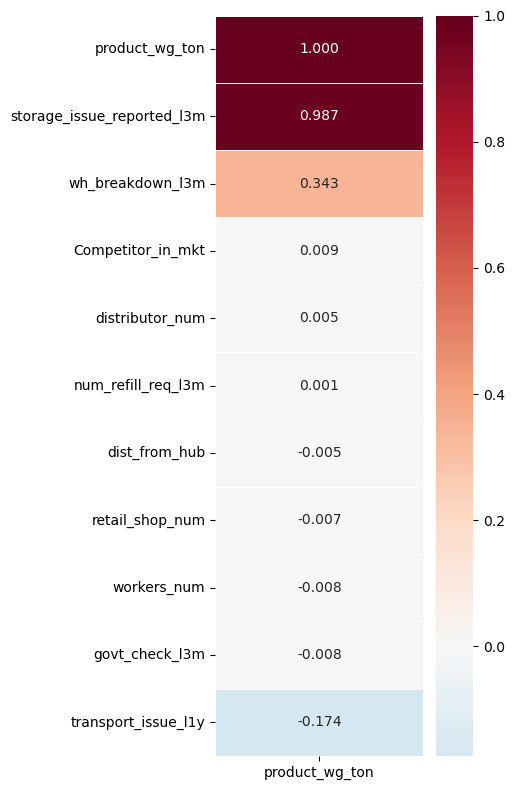

In [27]:
# correlation
print("=" * 40)
print("NUMERIC DATA CORRELATION")

print("=" * 40)
# numeric data
# numerik ccolumn
numeric_df = data.select_dtypes(include=['int64', 'float64'])

# Korelasi dengan target
corr_target = (
    numeric_df
    .corr()['product_wg_ton']
    .sort_values(ascending=False)
    .to_frame()
)

plt.figure(figsize=(5,8))
sns.heatmap(
    corr_target,
    annot=True,
    cmap="RdBu_r",
    center=0,
    fmt=".3f",
    linewidths=0.5
)

plt.tight_layout()
plt.show()

In [12]:
# save to excel
data.to_excel("../Data/Clean Data/FMCG_data_clean.xlsx", index = False)
print("Data berhasil disimpan di folder Clean Data.")

Data berhasil disimpan di folder Clean Data.
